# Hospital Readmission Risk: Predicting At-Risk Facilities

**Business problem:** Hospitals face CMS financial penalties for excess 30-day
readmissions. This notebook builds a model that flags which hospitals are
likely to fall into a High readmission-risk tier, using only characteristics
known about a hospital in advance (ownership, type, size, rating, region) —
not the readmission outcomes themselves.

**Why this matters:** A hospital operations or finance team could use a model
like this to proactively target quality-improvement resources at facilities
most likely to need them, rather than reacting after CMS penalties are
already assessed.


## 1. Load the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")

df = pd.read_csv("../data/modeling_dataset.csv")
print(df.shape)
df.head()


(2825, 21)


,facility_id,facility_name,address,citytown,countyparish,state,zip_code,telephone_number,hospital_type,hospital_ownership,...,hospital_overall_rating,hospital_overall_rating_footnote,meets_criteria_for_birthing_friendly_designation,loaded_at,conditions_reported,conditions_over_expected,avg_excess_readmission_ratio,total_discharges,total_readmissions,risk_tier
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,HOUSTON,AL,36301,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,4.0,NaN,Y,2026-07-31 00:22:03,6,1,0.978383,1692.0,280.0,Low
1,10005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,MARSHALL,AL,35957,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,3.0,NaN,Y,2026-07-31 00:22:03,4,1,0.918100,588.0,82.0,Low
2,10006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,LAUDERDALE,AL,35630,(256) 768-8400,Acute Care Hospitals,Proprietary,...,2.0,NaN,Y,2026-07-31 00:22:03,6,3,1.000217,1599.0,259.0,Medium
3,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,COVINGTON,AL,36467,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,1.0,NaN,NaN,2026-07-31 00:22:03,3,3,1.039900,123.0,28.0,Medium
4,10011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,JEFFERSON,AL,35235,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,3.0,29,NaN,2026-07-31 00:22:03,5,3,1.027460,787.0,136.0,Medium


## 2. Exploratory analysis

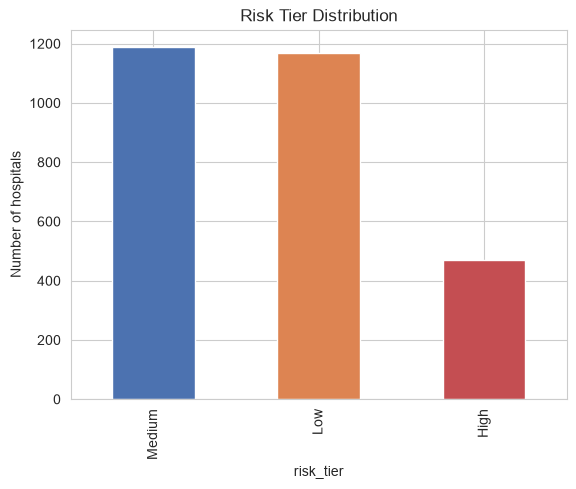

In [4]:
df['risk_tier'].value_counts().plot(
    kind='bar', title='Risk Tier Distribution', color=['#4C72B0','#DD8452','#C44E52']
)
plt.ylabel('Number of hospitals')
plt.show()


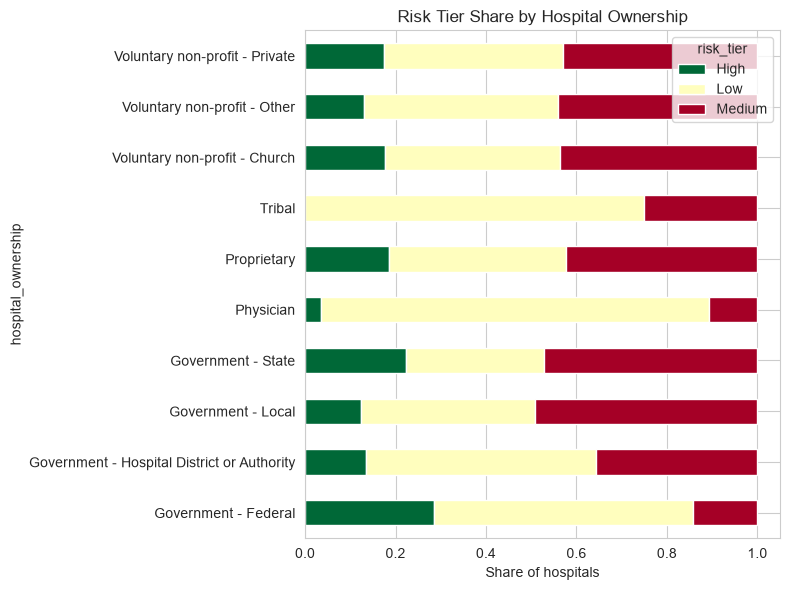

In [5]:
# Risk tier by ownership type
pd.crosstab(df['hospital_ownership'], df['risk_tier'], normalize='index') \
    .plot(kind='barh', stacked=True, figsize=(8,6), colormap='RdYlGn_r')
plt.title('Risk Tier Share by Hospital Ownership')
plt.xlabel('Share of hospitals')
plt.tight_layout()
plt.show()


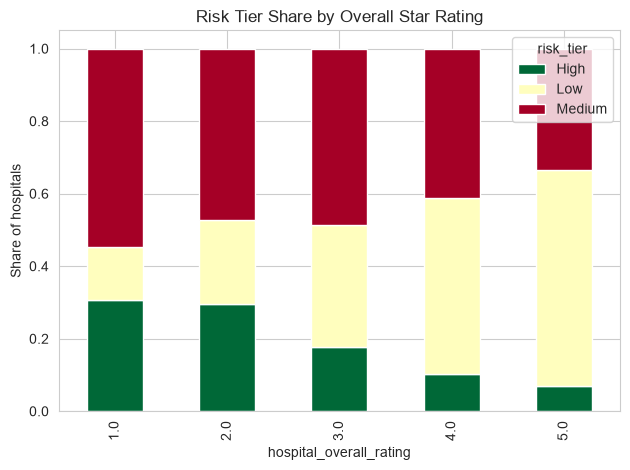

In [6]:
# Risk tier vs overall star rating
pd.crosstab(df['hospital_overall_rating'], df['risk_tier'], normalize='index') \
    .plot(kind='bar', stacked=True, colormap='RdYlGn_r')
plt.title('Risk Tier Share by Overall Star Rating')
plt.ylabel('Share of hospitals')
plt.tight_layout()
plt.show()


**A note on data leakage before modeling:**
`conditions_over_expected` and `avg_excess_readmission_ratio` were used to
*create* `risk_tier` — so they can't be used as model inputs, or the model
would just be looking up its own answer. The features below are limited to
things known about a hospital *before* looking at its readmission outcomes.


## 3. Feature selection & train/test split

In [7]:
FEATURES_CATEGORICAL = ['hospital_ownership', 'hospital_type', 'emergency_services']
FEATURES_NUMERIC = ['hospital_overall_rating', 'total_discharges', 'conditions_reported']
TARGET = 'risk_tier'

model_df = df.dropna(subset=FEATURES_CATEGORICAL + FEATURES_NUMERIC + [TARGET]).copy()
print(f"Rows available for modeling after dropping missing values: {len(model_df)}")

X = model_df[FEATURES_CATEGORICAL + FEATURES_NUMERIC]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")


Rows available for modeling after dropping missing values: 2628
Train: 1971  Test: 657


## 4. Build a preprocessing + model pipeline

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CATEGORICAL),
], remainder='passthrough')

logreg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

tree_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)),
])

logreg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


c:\Users\Lavanya\Desktop\da-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Evaluate honestly




In [9]:
for name, pipeline in [('Logistic Regression', logreg_pipeline), ('Decision Tree', tree_pipeline)]:
    preds = pipeline.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))


--- Logistic Regression ---
              precision    recall  f1-score   support

        High       0.36      0.66      0.47       117
         Low       0.63      0.60      0.61       245
      Medium       0.55      0.40      0.46       295

    accuracy                           0.52       657
   macro avg       0.51      0.55      0.51       657
weighted avg       0.55      0.52      0.52       657

--- Decision Tree ---
              precision    recall  f1-score   support

        High       0.37      0.62      0.46       117
         Low       0.64      0.58      0.61       245
      Medium       0.54      0.44      0.49       295

    accuracy                           0.53       657
   macro avg       0.52      0.55      0.52       657
weighted avg       0.55      0.53      0.53       657



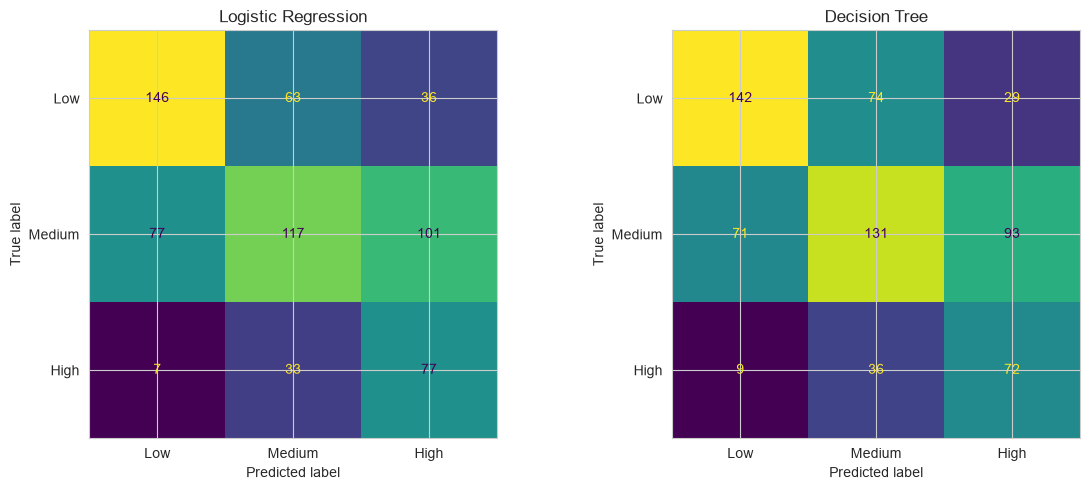

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, (name, pipeline) in zip(axes, [('Logistic Regression', logreg_pipeline), ('Decision Tree', tree_pipeline)]):
    preds = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=['Low','Medium','High'])
    ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 6. What drives the prediction? (interpretability)

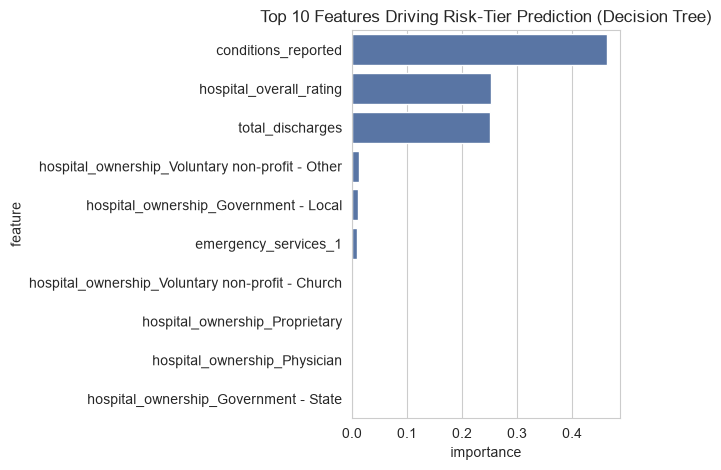

In [11]:
# Decision tree feature importance — easy to explain to a non-technical audience
feature_names = (
    tree_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(FEATURES_CATEGORICAL)
).tolist() + FEATURES_NUMERIC

importances = tree_pipeline.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(10)

sns.barplot(data=imp_df, y='feature', x='importance', color='#4C72B0')
plt.title('Top 10 Features Driving Risk-Tier Prediction (Decision Tree)')
plt.tight_layout()
plt.show()


## 7. Business takeaway



Example structure:
- "The model correctly identifies **X%** of actual High-risk hospitals (recall),
  with **Y%** precision — meaning when it flags a hospital as High-risk, it's
  right Y% of the time."
- "The strongest predictors of risk tier are [feature names from the chart above] —
  suggesting [ownership type / size / region] plays a meaningful role."
- "**Limitation:** this dataset doesn't include CMS's official penalty dollar
  amounts (published separately). A natural next step would be to merge in
  that supplemental file to translate risk tier into estimated dollars at stake."
- "**Recommended action:** hospital ops teams could use this model to
  proactively prioritize quality-improvement review for facilities flagged
  High-risk, rather than waiting for CMS penalty notices."
